#  Bahrain Rental Price Prediction


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Better display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Preprocessing tools
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


In [57]:
train = pd.read_csv('data.csv')
test = pd.read_csv('test.csv')

print("Training data shape (train):", train.shape)
print("Test data shape (test):", test.shape)

Training data shape (train): (10578, 16)
Test data shape (test): (3527, 15)


In [58]:
train.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities,rent
0,6046,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Inclusive,BTRAND NEW LUXURY VILLA FOR RENT AMWAJ,"Amwaj Avenue, Amwaj Islands",Muharraq Governorate,3+ Maid,4,"2,368 sqft / 220 sqm",9 Apr 2025,Savio Fernandes,Almoayyed property solutions,6.0,1000.0
1,2240,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,First Resident | Quiet Area | Luxurious,Diyar Al Muharraq,Muharraq Governorate,5,6,"3,229 sqft / 300 sqm",16 Sep 2025,Al Lagoon Real Estate,Al Lagoon Real Estate,5.0,700.0
2,6248,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Studio Apartment for rent located in Juffair,Al Juffair,Capital Governorate,studio,1,484 sqft / 45 sqm,17 Aug 2025,Najeeb Hejres,Green Line Real Estate,12.0,260.0
3,7177,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,Apartment for Rent in Jidhafs – Prime Location,Jidhafs,Northern Governorate,3,3,"1,507 sqft / 140 sqm",6 Aug 2025,Sayed Sadeq Jaafar,Grnata Real Estate,2.0,250.0
4,7842,Rent,https://www.propertyfinder.bh/en/plp/rent/vill...,Villa,Exclusive,Navy Approved| 5 BR | Private Pool |Gardens,Al Juffair,Capital Governorate,5+ Maid,5,"4,844 sqft / 450 sqm",30 Jul 2025,Zsuzsanna Gecse,Arabian Homes Properties,13.0,1280.0


In [59]:
test.head()

,Property_id,Offer,URL,Property_type,Include_w_e,Title,Area,Governorate,Beds,Baths,Size,Availability_date,Agent_name,Agency,Amenities
0,4394,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,PRIME LOCATION | NEWLY RENOVATED | MODERN 2BHK,"Sanabis, Manama",Capital Governorate,2,2,"1,313 sqft / 122 sqm",3 Sep 2025,Loai Bitar,Instant Homz,11.0
1,2338,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,2BR High-Rise | Juffair | Jacuzzi| Navy Approved,Al Juffair,Capital Governorate,2,2,"1,938 sqft / 180 sqm",15 Sep 2025,Shaji Kottathazham,AIM REAL ESTATE,12.0
2,8531,Rent,https://www.propertyfinder.bh/en/plp/rent/comp...,Compound,Exclusive,Beautiful modern villa in compound,Jannusan,Northern Governorate,3+ Maid,4,"3,767 sqft / 350 sqm",15 Jul 2025,Aysha Adil,301 REALESTATE,16.0
3,8952,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Inclusive,Affordable Spacious Bright In The Heart Of Saar,Saar,Northern Governorate,2,2,"1,292 sqft / 120 sqm",8 Jul 2025,Tariq Fatehi Abdelrahman Aboughazeh,Soulmate Management,6.0
4,11064,Rent,https://www.propertyfinder.bh/en/plp/rent/apar...,Apartment,Exclusive,luxury | spacious design | Fully Furnished,Saar,Northern Governorate,1,1,"1,055 sqft / 98 sqm",8 Apr 2025,Aby N,4You Properties,5.0


## (EDA)


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10578 entries, 0 to 10577
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Property_id        10578 non-null  int64  
 1   Offer              10578 non-null  object 
 2   URL                10578 non-null  object 
 3   Property_type      10578 non-null  object 
 4   Include_w_e        10578 non-null  object 
 5   Title              10575 non-null  object 
 6   Area               10575 non-null  object 
 7   Governorate        10575 non-null  object 
 8   Beds               10578 non-null  object 
 9   Baths              10578 non-null  object 
 10  Size               10578 non-null  object 
 11  Availability_date  10059 non-null  object 
 12  Agent_name         10575 non-null  object 
 13  Agency             10575 non-null  object 
 14  Amenities          10272 non-null  float64
 15  rent               10575 non-null  float64
dtypes: float64(2), int64(1

In [10]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Property_id,10578.0,NaN,NaN,NaN,7059.73426,4080.910374,2.0,3521.25,7023.5,10605.75,14103.0
Offer,10578,1,Rent,10578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
URL,10578,10337,https://www.propertyfinder.bh/en/plp/rent/apar...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Property_type,10578,11,Apartment,8378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Include_w_e,10578,2,Inclusive,6477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,10575,9824,"Apartment for rent , in a great location:",18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,10575,127,Al Juffair,1914,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Governorate,10575,5,Capital Governorate,5308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Beds,10578,19,2,3874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Baths,10578,9,2,4260,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100

missing_df = pd.DataFrame({'Missing Count': missing, 'Percent %': missing_percent.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_df

,Missing Count,Percent %
Availability_date,519,4.91
Amenities,306,2.89
Title,3,0.03
Area,3,0.03
Governorate,3,0.03
Agent_name,3,0.03
Agency,3,0.03
rent,3,0.03


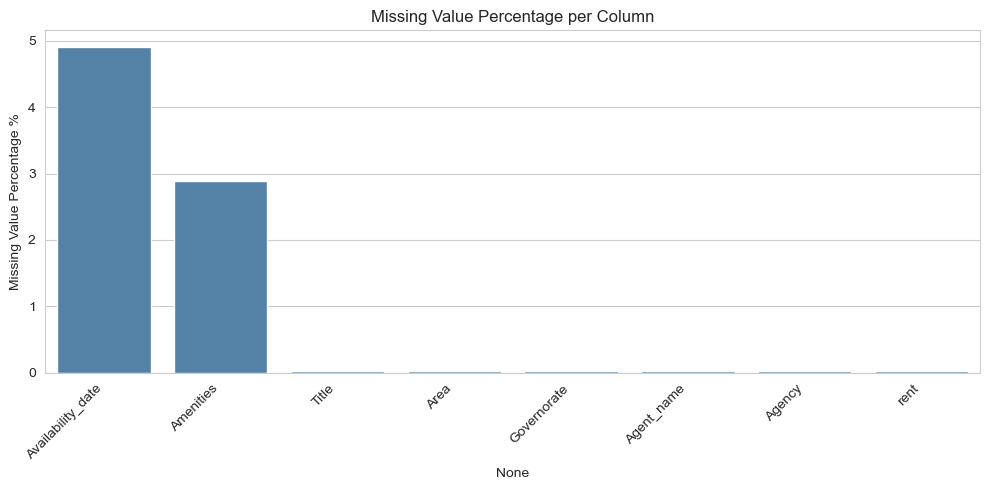

In [61]:
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Percent %'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing Value Percentage %')
plt.title('Missing Value Percentage per Column')
plt.tight_layout()
plt.show()

In [13]:
print("Number of fully duplicated rows:", train.duplicated().sum())
print("Number of duplicated rows (excluding Property_id and URL):",
      train.drop(columns=['Property_id', 'URL']).duplicated().sum())

Number of fully duplicated rows: 0
Number of duplicated rows (excluding Property_id and URL): 269


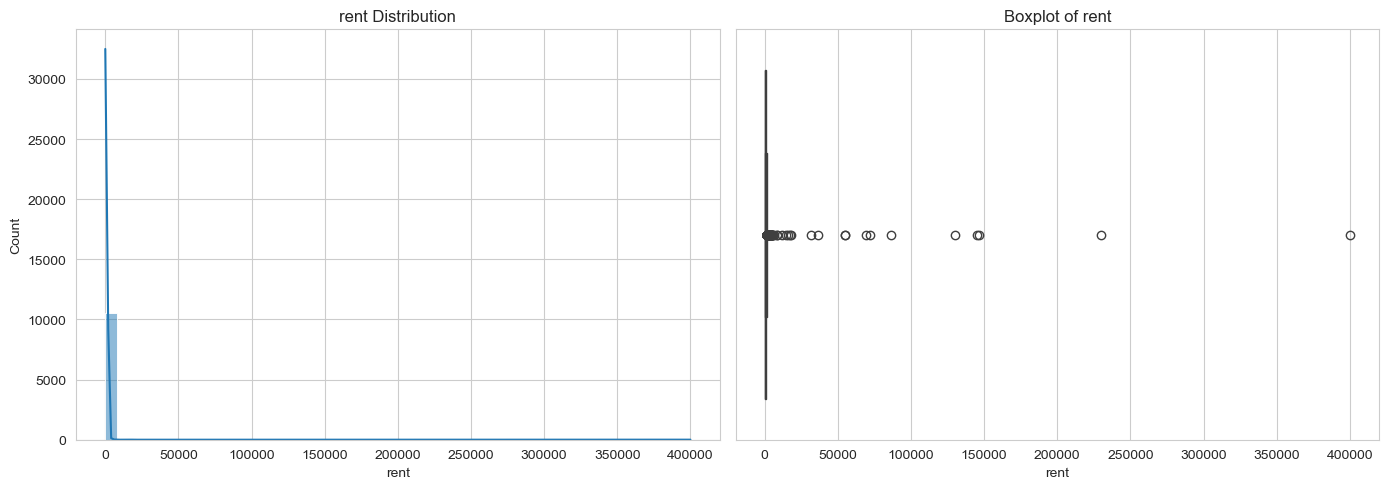

count     10575.000000
mean        718.750071
std        5318.027519
min          50.000000
25%         330.000000
50%         450.000000
75%         700.000000
max      400000.000000
Name: rent, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['rent'].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].set_title('rent Distribution')

sns.boxplot(x=train['rent'].dropna(), ax=axes[1])
axes[1].set_title('Boxplot of rent')

plt.tight_layout()
plt.show()

print(train['rent'].describe())

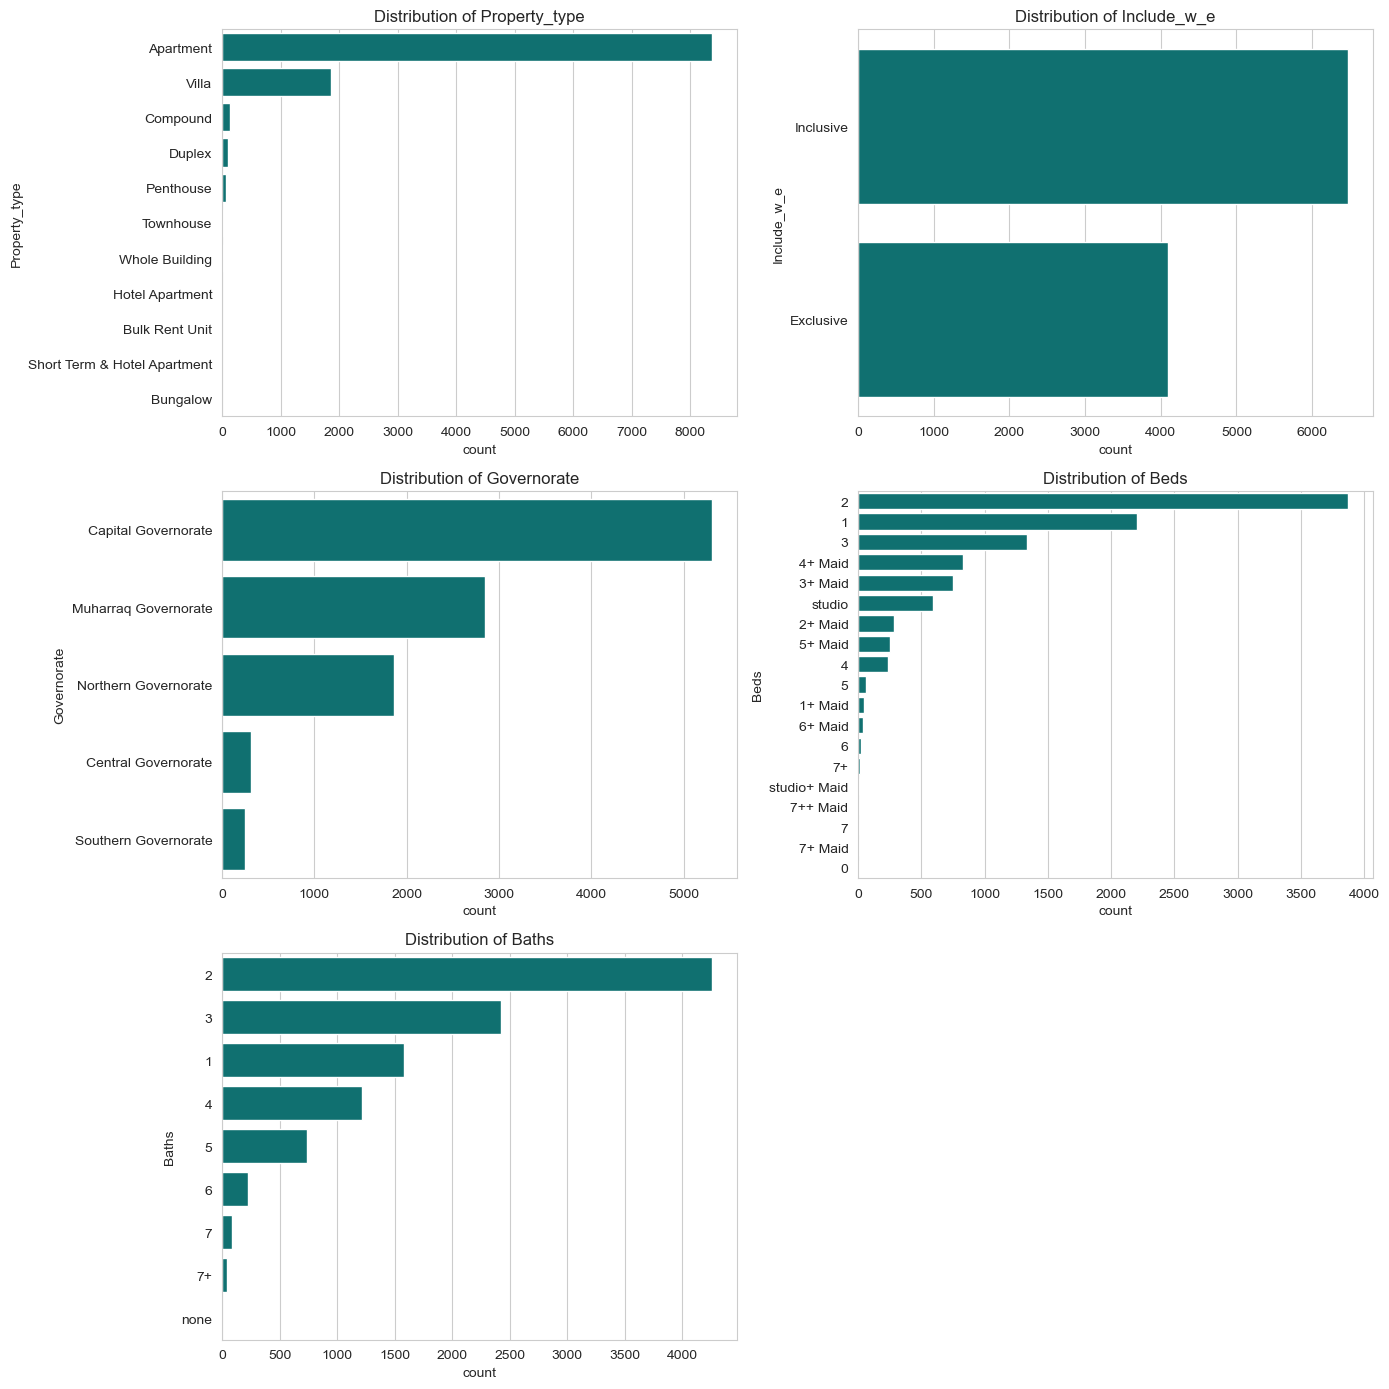

In [15]:
categorical_cols_overview = ['Property_type', 'Include_w_e', 'Governorate', 'Beds', 'Baths']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols_overview):
    order = train[col].value_counts().index
    sns.countplot(y=train[col], order=order, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

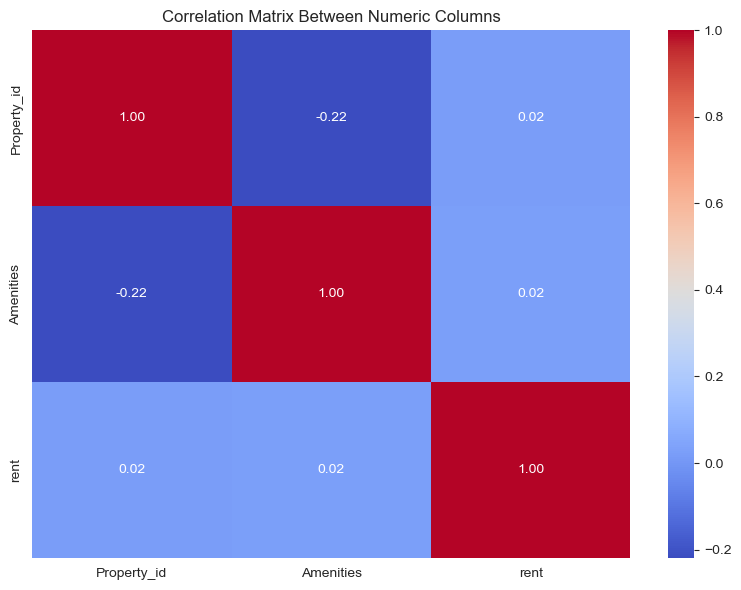

In [16]:
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(train[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Between Numeric Columns')
plt.tight_layout()
plt.show()

In [17]:
# Drop rows where rent (the target) is missing
print("Number of rows before dropping:", train.shape[0])
train = train.dropna(subset=['rent']).reset_index(drop=True)
print("Number of rows after dropping missing rent:", train.shape[0])

Number of rows before dropping: 10578
Number of rows after dropping missing rent: 10575


In [55]:
# Fill categorical columns with few missing values using the Mode
for col in ['Title', 'Area', 'Governorate', 'Agent_name', 'Agency']:
    for df in [train, test]:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values in low-missing categorical columns filled ")

Missing values in low-missing categorical columns filled 


In [19]:
# Fill Amenities with the Median (since it's a numeric column that may contain outliers, and the Median is more robust to them than the Mean)
amenities_median = train['Amenities'].median()
train['Amenities'] = train['Amenities'].fillna(amenities_median)
test['Amenities'] = test['Amenities'].fillna(amenities_median)

Median used to fill Amenities: 11.0


In [20]:
# Convert Availability_date to date type
train['Availability_date'] = pd.to_datetime(train['Availability_date'], errors='coerce')
test['Availability_date'] = pd.to_datetime(test['Availability_date'], errors='coerce')

# For missing values, fill with the most frequent date (Mode)
avail_mode = train['Availability_date'].mode()[0]
train['Availability_date'] = train['Availability_date'].fillna(avail_mode)
test['Availability_date'] = test['Availability_date'].fillna(avail_mode)

Missing values in Availability_date handled ✅
Final check of missing values in train:
0 missing values remaining


In [21]:
def extract_beds(x):
    x = str(x).lower().strip()
    if 'studio' in x:
        return 0
    # take the first number found in the text
    digits = ''.join([c for c in x if c.isdigit()])
    return int(digits) if digits != '' else np.nan

def extract_has_maid(x):
    return 1 if 'maid' in str(x).lower() else 0

def extract_baths(x):
    x = str(x).lower().strip()
    if x == 'none':
        return 0
    digits = ''.join([c for c in x if c.isdigit()])
    return int(digits) if digits != '' else np.nan

def extract_size_sqft(x):
    # format like: '2,368 sqft / 220 sqm'
    try:
        sqft_part = str(x).split('sqft')[0].replace(',', '').strip()
        return float(sqft_part)
    except:
        return np.nan

for df in [train, test]:
    df['Beds_num'] = df['Beds'].apply(extract_beds)
    df['Has_Maid_Room'] = df['Beds'].apply(extract_has_maid)
    df['Baths_num'] = df['Baths'].apply(extract_baths)
    df['Size_sqft'] = df['Size'].apply(extract_size_sqft)
    df['Availability_Month'] = df['Availability_date'].dt.month

train[['Beds', 'Beds_num', 'Has_Maid_Room', 'Baths', 'Baths_num', 'Size', 'Size_sqft', 'Availability_Month']].head(10)

,Beds,Beds_num,Has_Maid_Room,Baths,Baths_num,Size,Size_sqft,Availability_Month
0,3+ Maid,3,1,4,4,"2,368 sqft / 220 sqm",2368.0,4
1,5,5,0,6,6,"3,229 sqft / 300 sqm",3229.0,9
2,studio,0,0,1,1,484 sqft / 45 sqm,484.0,8
3,3,3,0,3,3,"1,507 sqft / 140 sqm",1507.0,8
4,5+ Maid,5,1,5,5,"4,844 sqft / 450 sqm",4844.0,7
5,2,2,0,3,3,"1,238 sqft / 115 sqm",1238.0,9
6,4+ Maid,4,1,4,4,"3,014 sqft / 280 sqm",3014.0,8
7,4+ Maid,4,1,5,5,"4,898 sqft / 455 sqm",4898.0,9
8,2,2,0,2,2,"1,615 sqft / 150 sqm",1615.0,9
9,1,1,0,2,2,"1,001 sqft / 93 sqm",1001.0,5


In [54]:
# Make sure no new NaNs appeared after extraction, and fill them with the Median if any
for col in ['Beds_num', 'Baths_num', 'Size_sqft']:
    if train[col].isnull().sum() > 0 or test[col].isnull().sum() > 0:
        med = train[col].median()
        train[col] = train[col].fillna(med)
        test[col] = test[col].fillna(med)
        print(f"Missing values in {col} filled with Median = {med}")

print("\nNo missing values remain in the new columns " if train[['Beds_num','Baths_num','Size_sqft']].isnull().sum().sum()==0 else "There are still missing values!")


No missing values remain in the new columns 


In [23]:
train['rent_per_sqft'] = train['rent'] / train['Size_sqft']
print(train['rent_per_sqft'].describe())
# We'll use this column only to detect outliers in the next step, then drop it before training

count    10575.000000
mean         1.019852
std          6.923181
min          0.028662
25%          0.250179
50%          0.325279
75%          0.447350
max        200.000000
Name: rent_per_sqft, dtype: float64


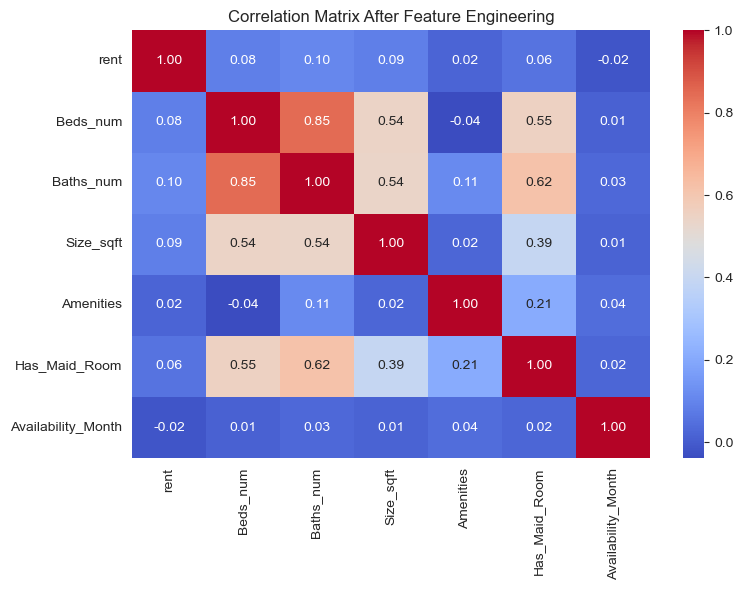

In [24]:
new_numeric_cols = ['rent', 'Beds_num', 'Baths_num', 'Size_sqft', 'Amenities', 'Has_Maid_Room', 'Availability_Month']
plt.figure(figsize=(8, 6))
sns.heatmap(train[new_numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix After Feature Engineering')
plt.tight_layout()
plt.show()

In [25]:
cols_to_drop = ['URL', 'Title', 'Agent_name', 'Agency', 'Offer',
                'Beds', 'Baths', 'Size', 'Availability_date', 'rent_per_sqft']

train_clean = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
test_clean = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

print("train columns after cleaning:", list(train_clean.columns))

train columns after cleaning: ['Property_id', 'Property_type', 'Include_w_e', 'Area', 'Governorate', 'Amenities', 'rent', 'Beds_num', 'Has_Maid_Room', 'Baths_num', 'Size_sqft', 'Availability_Month']


In [26]:
lower_bound = train_clean['rent'].quantile(0.01)
upper_bound = train_clean['rent'].quantile(0.99)

before = train_clean.shape[0]
train_clean = train_clean[(train_clean['rent'] >= lower_bound) & (train_clean['rent'] <= upper_bound)].reset_index(drop=True)
after = train_clean.shape[0]

print(f"Lower bound (1st percentile): {lower_bound}")
print(f"Upper bound (99th percentile): {upper_bound}")
print(f"Number of rows dropped: {before - after} out of {before} ({(before-after)/before*100:.1f}%)")


Lower bound (1st percentile): 150.0
Upper bound (99th percentile): 2100.0
Number of rows dropped: 179 out of 10575 (1.7%)


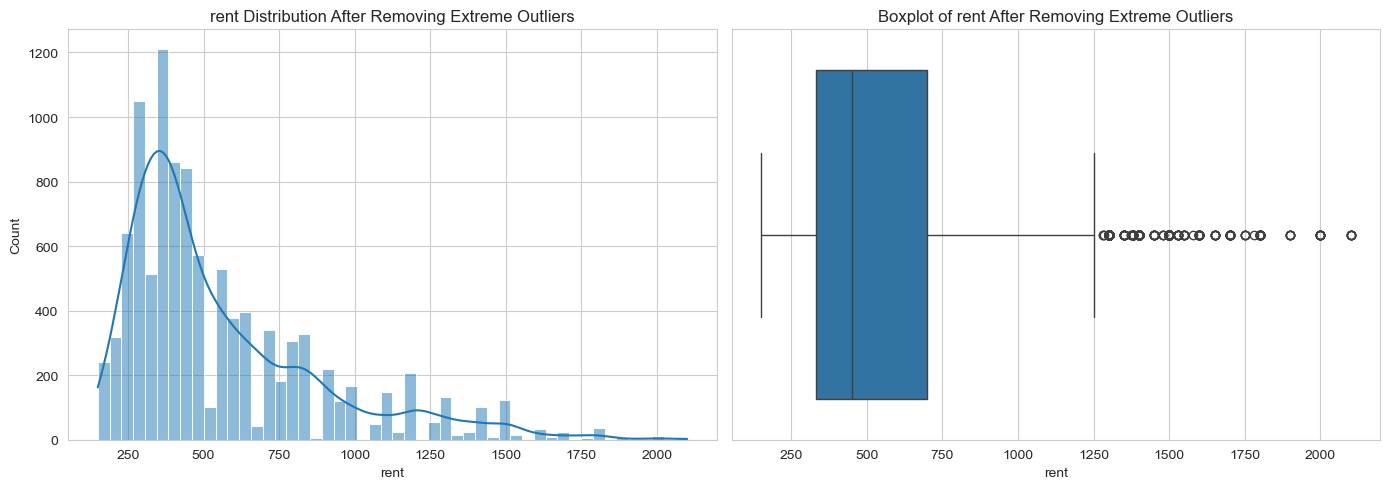

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_clean['rent'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('rent Distribution After Removing Extreme Outliers')
sns.boxplot(x=train_clean['rent'], ax=axes[1])
axes[1].set_title('Boxplot of rent After Removing Extreme Outliers')
plt.tight_layout()
plt.show()

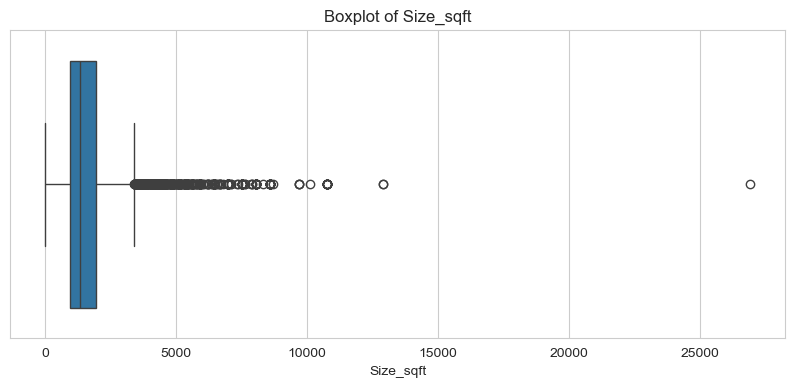

Number of rows dropped due to extreme Size_sqft: 81


In [28]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=train_clean['Size_sqft'])
plt.title('Boxplot of Size_sqft')
plt.show()

lower_s = train_clean['Size_sqft'].quantile(0.01)
upper_s = train_clean['Size_sqft'].quantile(0.99)

before = train_clean.shape[0]
train_clean = train_clean[(train_clean['Size_sqft'] >= lower_s) & (train_clean['Size_sqft'] <= upper_s)].reset_index(drop=True)
after = train_clean.shape[0]
print(f"Number of rows dropped due to extreme Size_sqft: {before - after}")


##  Skewness Analysis


In [29]:
numeric_features_for_skew = ['rent', 'Size_sqft', 'Amenities', 'Beds_num', 'Baths_num']

skew_values = train_clean[numeric_features_for_skew].skew().sort_values(ascending=False)
print(skew_values)

Size_sqft    1.765991
rent         1.500548
Baths_num    0.928614
Beds_num     0.538842
Amenities   -0.030996
dtype: float64


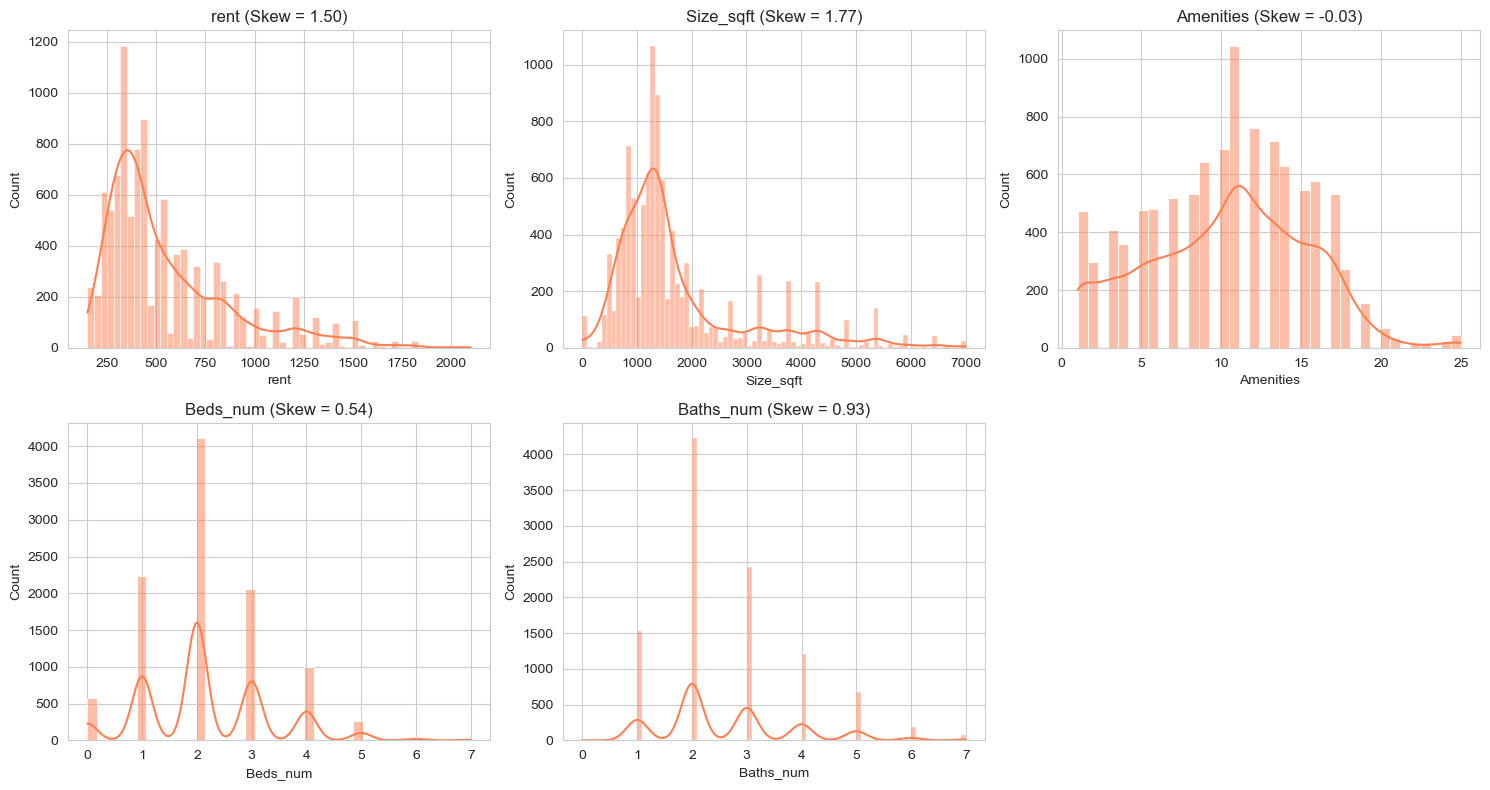

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_features_for_skew):
    sns.histplot(train_clean[col], kde=True, ax=axes[i], color='coral')
    axes[i].set_title(f'{col} (Skew = {train_clean[col].skew():.2f})')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

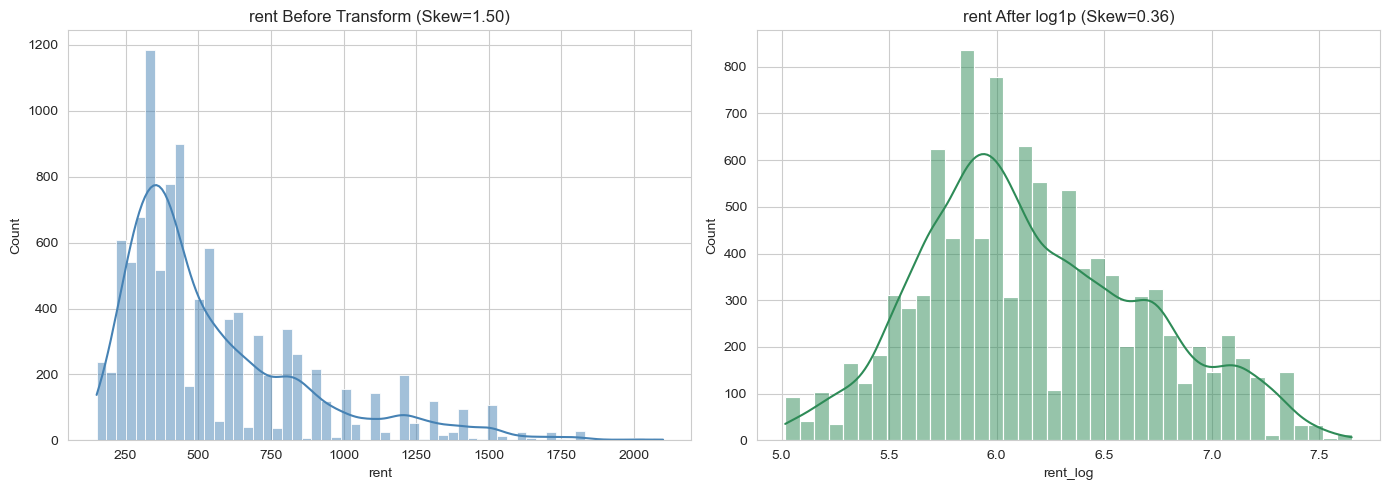

In [31]:
train_clean['rent_log'] = np.log1p(train_clean['rent'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_clean['rent'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"rent Before Transform (Skew={train_clean['rent'].skew():.2f})")

sns.histplot(train_clean['rent_log'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f"rent After log1p (Skew={train_clean['rent_log'].skew():.2f})")

plt.tight_layout()
plt.show()

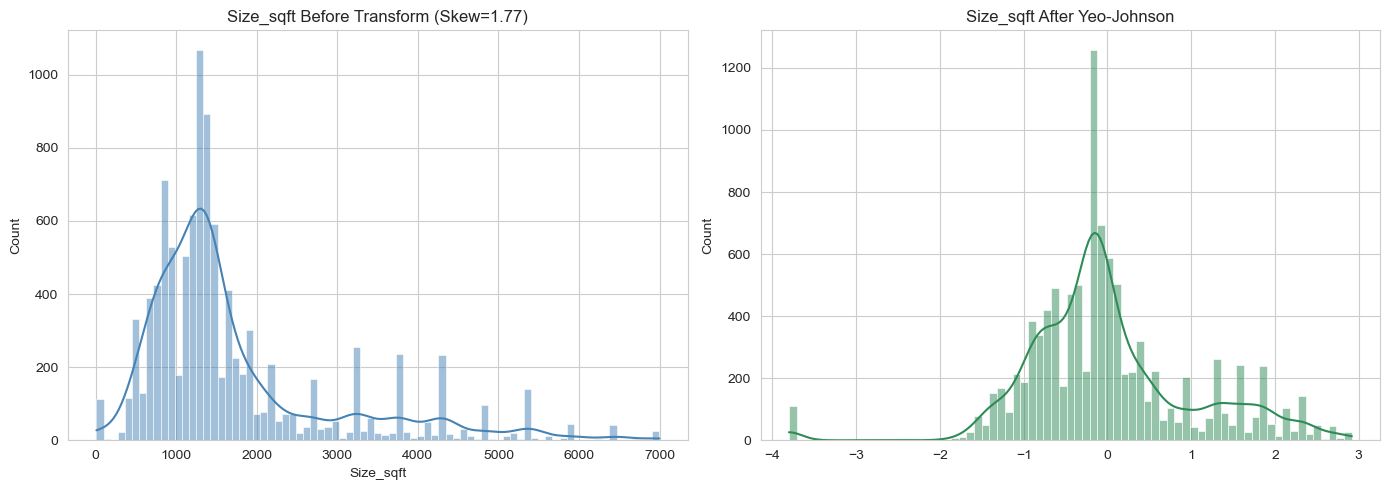

In [32]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
size_transformed = pt.fit_transform(train_clean[['Size_sqft']])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_clean['Size_sqft'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"Size_sqft Before Transform (Skew={train_clean['Size_sqft'].skew():.2f})")

sns.histplot(size_transformed.ravel(), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title("Size_sqft After Yeo-Johnson")

plt.tight_layout()
plt.show()

##  Encoding, Scaling, and ColumnTransformer


In [33]:
categorical_features = ['Property_type', 'Include_w_e', 'Governorate', 'Area']
numeric_features = ['Beds_num', 'Baths_num', 'Has_Maid_Room', 'Availability_Month']
skewed_features = ['Size_sqft', 'Amenities']

print("Number of categorical columns:", len(categorical_features))
print("Number of regular numeric columns:", len(numeric_features))
print("Number of skewed numeric columns:", len(skewed_features))

Number of categorical columns: 4
Number of regular numeric columns: 4
Number of skewed numeric columns: 2


In [34]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

skewed_transformer = Pipeline(steps=[
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('cat', categorical_transformer, categorical_features),
    ('num', numeric_transformer, numeric_features),
    ('skewed', skewed_transformer, skewed_features)
])

preprocessor

ColumnTransformer(transformers=[('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Property_type', 'Include_w_e', 'Governorate',
                                  'Area']),
                                ('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Beds_num', 'Baths_num', 'Has_Maid_Room',
                                  'Availability_Month']),
                                ('skewed',
                                 Pipeline(steps=[('power', PowerTransformer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Size_sqft', 'Amenities'])])

## Pipeline &  Train/Test Split
prepare X and y, then split the training data into Train/Test (80%/20%).

In [35]:
feature_cols = categorical_features + numeric_features + skewed_features

X = train_clean[feature_cols]
y = train_clean['rent_log']          # we train on the log-transformed value
y_original = train_clean['rent']     # we keep the original value to compute MAE on the real scale (BHD)

X_train, X_val, y_train, y_val, y_train_orig, y_val_orig = train_test_split(
    X, y, y_original, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Validation data size:", X_val.shape)

Training data size: (8252, 10)
Validation data size: (2063, 10)


## Baseline Model — Linear Regression



In [36]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

baseline_pipeline.fit(X_train, y_train)

pred_log = baseline_pipeline.predict(X_val)
pred_baseline = np.expm1(pred_log)   # convert back to the original scale (BHD) by inverting log1p

pred_baseline = np.clip(pred_baseline, 0, None)  # rent can't be negative

## Evaluation — MAE / RMSE / R² / Residual Plot



In [37]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate_model(y_val_orig, pred_baseline, "Linear Regression (Baseline)"))

--- Linear Regression (Baseline) ---
MAE  : 110.54
RMSE : 172.30
R²   : 0.7149


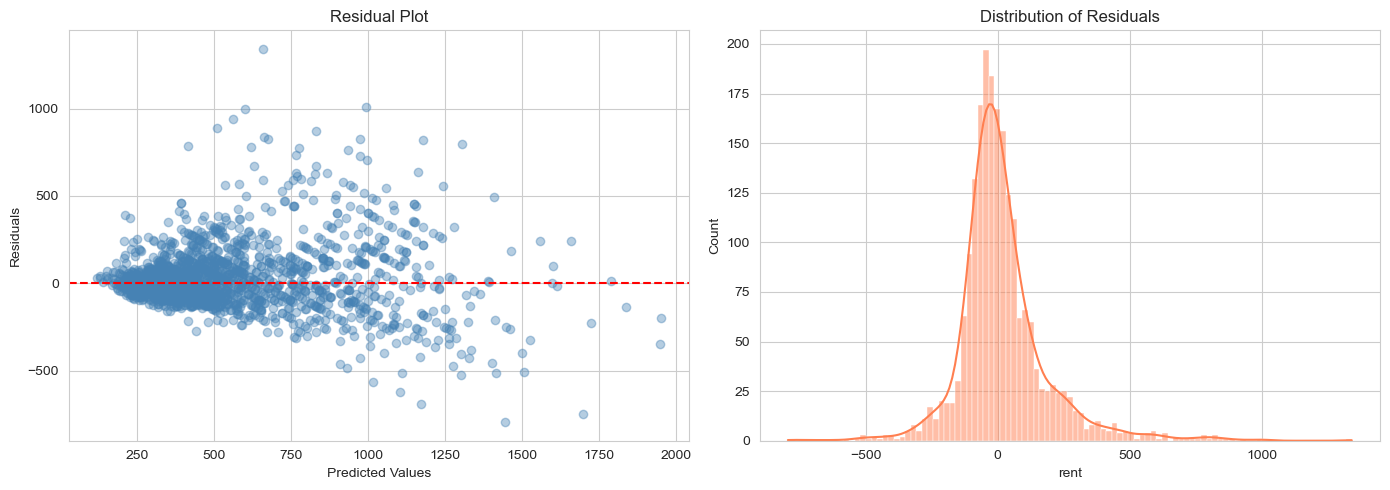

In [38]:
residuals = y_val_orig - pred_baseline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pred_baseline, residuals, alpha=0.4, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

sns.histplot(residuals, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

##  Ridge / Lasso / ElasticNet / Decision Tree / KNN / Random Forest


In [39]:
models = {
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.01, random_state=42, max_iter=5000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=5000),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=7, weights='distance'),
    'Random Forest': RandomForestRegressor(n_estimators=300, max_depth=None, min_samples_leaf=2,
                                            random_state=42, n_jobs=-1)
}

fitted_pipelines = {'Linear Regression (Baseline)': baseline_pipeline}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    pred_log = pipe.predict(X_val)
    pred = np.clip(np.expm1(pred_log), 0, None)

    results.append(evaluate_model(y_val_orig, pred, name))
    fitted_pipelines[name] = pipe

--- Ridge ---
MAE  : 110.53
RMSE : 172.36
R²   : 0.7147
--- Lasso ---
MAE  : 131.04
RMSE : 201.88
R²   : 0.6086
--- ElasticNet ---
MAE  : 126.59
RMSE : 196.18
R²   : 0.6304
--- Decision Tree ---
MAE  : 116.52
RMSE : 181.51
R²   : 0.6836
--- KNN ---
MAE  : 103.45
RMSE : 168.90
R²   : 0.7260
--- Random Forest ---
MAE  : 101.06
RMSE : 160.57
R²   : 0.7524


In [40]:
results_df = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Random Forest,101.064124,160.572467,0.752381
1,KNN,103.446438,168.899077,0.726034
2,Ridge,110.529814,172.364850,0.714675
3,Linear Regression (Baseline),110.540608,172.296918,0.714900
4,Decision Tree,116.519536,181.512186,0.683587
5,ElasticNet,126.587394,196.180224,0.630382
6,Lasso,131.038442,201.880229,0.608592


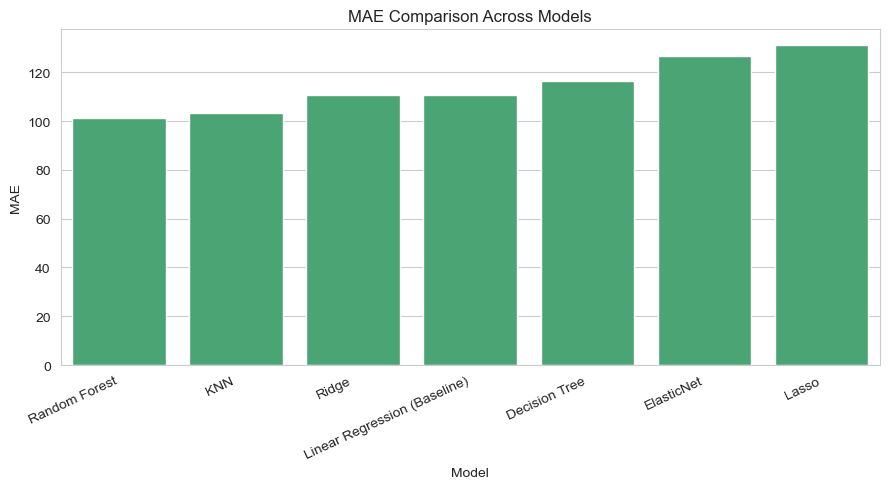

In [41]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x='Model', y='MAE', color='mediumseagreen')
plt.xticks(rotation=25, ha='right')
plt.title('MAE Comparison Across Models')
plt.tight_layout()
plt.show()

##  Cross Validation


In [42]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
all_models = {'Linear Regression': LinearRegression(), **models}

for name, model in all_models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
    mae_scores = -scores  # errors on the log1p scale (only for relative comparison between models)
    cv_results.append({'Model': name, 'CV MAE (log scale) Mean': mae_scores.mean(), 'CV MAE (log scale) Std': mae_scores.std()})
    print(f"{name}: MAE (log scale) = {mae_scores.mean():.4f} (+/- {mae_scores.std():.4f})")

cv_results_df = pd.DataFrame(cv_results).sort_values('CV MAE (log scale) Mean').reset_index(drop=True)
cv_results_df

Linear Regression: MAE (log scale) = 27831725.0481 (+/- 33653001.1082)
Ridge: MAE (log scale) = 0.1898 (+/- 0.0011)
Lasso: MAE (log scale) = 0.2297 (+/- 0.0039)
ElasticNet: MAE (log scale) = 0.2202 (+/- 0.0037)
Decision Tree: MAE (log scale) = 0.2004 (+/- 0.0030)
KNN: MAE (log scale) = 0.1754 (+/- 0.0028)
Random Forest: MAE (log scale) = 0.1736 (+/- 0.0015)


,Model,CV MAE (log scale) Mean,CV MAE (log scale) Std
0,Random Forest,1.736379e-01,1.536415e-03
1,KNN,1.754498e-01,2.848826e-03
2,Ridge,1.897880e-01,1.111553e-03
3,Decision Tree,2.003835e-01,3.038990e-03
4,ElasticNet,2.202204e-01,3.734164e-03
5,Lasso,2.296765e-01,3.945122e-03
6,Linear Regression,2.783173e+07,3.365300e+07


##  GridSearchCV & RandomizedSearchCV


In [43]:
best_model_name = results_df.iloc[0]['Model']
print("Best model so far by MAE on the Validation set:", best_model_name)

Best model so far by MAE on the Validation set: Random Forest


In [44]:
# Build a Pipeline with a tunable alpha, using Ridge as an example (can be swapped for any other model the same way)
tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge(random_state=42))
])

param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best MAE (log scale) during search:", -grid_search.best_score_)

Best alpha: {'model__alpha': 0.1}
Best MAE (log scale) during search: 0.18919616769360864


In [45]:
best_ridge_pipeline = grid_search.best_estimator_

pred_log = best_ridge_pipeline.predict(X_val)
pred_tuned = np.clip(np.expm1(pred_log), 0, None)

tuned_result = evaluate_model(y_val_orig, pred_tuned, "Ridge (Tuned via GridSearchCV)")
results.append(tuned_result)

results_df_final = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df_final

--- Ridge (Tuned via GridSearchCV) ---
MAE  : 110.52
RMSE : 172.29
R²   : 0.7149


,Model,MAE,RMSE,R2
0,Random Forest,101.064124,160.572467,0.752381
1,KNN,103.446438,168.899077,0.726034
2,Ridge (Tuned via GridSearchCV),110.523684,172.292315,0.714915
3,Ridge,110.529814,172.364850,0.714675
4,Linear Regression (Baseline),110.540608,172.296918,0.714900
5,Decision Tree,116.519536,181.512186,0.683587
6,ElasticNet,126.587394,196.180224,0.630382
7,Lasso,131.038442,201.880229,0.608592


### Tuning Random Forest with RandomizedSearchCV


In [47]:
rf_tuning_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    'model__n_estimators': [200, 300, 400, 600],
    'model__max_depth': [None, 10, 15, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}

rf_random_search = RandomizedSearchCV(
    rf_tuning_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print("Best Random Forest hyperparameters:", rf_random_search.best_params_)
print("Best MAE (log scale) during search:", -rf_random_search.best_score_)

Best Random Forest hyperparameters: {'model__n_estimators': 400, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best MAE (log scale) during search: 0.16921615990611585


In [48]:
best_rf_pipeline = rf_random_search.best_estimator_

pred_log = best_rf_pipeline.predict(X_val)
pred_rf_tuned = np.clip(np.expm1(pred_log), 0, None)

rf_tuned_result = evaluate_model(y_val_orig, pred_rf_tuned, "Random Forest (Tuned via RandomizedSearchCV)")
results.append(rf_tuned_result)

results_df_final = pd.DataFrame(results).sort_values('MAE').reset_index(drop=True)
results_df_final

--- Random Forest (Tuned via RandomizedSearchCV) ---
MAE  : 98.09
RMSE : 157.56
R²   : 0.7616


,Model,MAE,RMSE,R2
0,Random Forest (Tuned via RandomizedSearchCV),98.092493,157.555603,0.761598
1,Random Forest,101.064124,160.572467,0.752381
2,KNN,103.446438,168.899077,0.726034
3,Ridge (Tuned via GridSearchCV),110.523684,172.292315,0.714915
4,Ridge,110.529814,172.364850,0.714675
5,Linear Regression (Baseline),110.540608,172.296918,0.714900
6,Decision Tree,116.519536,181.512186,0.683587
7,ElasticNet,126.587394,196.180224,0.630382
8,Lasso,131.038442,201.880229,0.608592


##  Choosing the Model

In [49]:
best_row = results_df_final.iloc[0]
print("Final best model:", best_row['Model'])
print(best_row)

Final best model: Random Forest (Tuned via RandomizedSearchCV)
Model    Random Forest (Tuned via RandomizedSearchCV)
MAE                                         98.092493
RMSE                                       157.555603
R2                                           0.761598
Name: 0, dtype: object


In [50]:
# Map from name to the trained Pipeline 
pipelines_map = {
    **fitted_pipelines,
    'Ridge (Tuned via GridSearchCV)': best_ridge_pipeline,
    'Random Forest (Tuned via RandomizedSearchCV)': best_rf_pipeline
}

best_model_name_final = best_row['Model']
chosen_pipeline = pipelines_map[best_model_name_final]

final_model = chosen_pipeline.named_steps['model']
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])

final_pipeline.fit(X, y)   
print("Final model trained on the entire training dataset ")

Final model trained on the entire training dataset ✅


In [51]:
X_test_final = test_clean[feature_cols]

test_pred_log = final_pipeline.predict(X_test_final)
test_pred = np.clip(np.expm1(test_pred_log), 0, None)   # invert log1p + disallow negative values

test_pred[:10]

array([435.29656363, 595.48739671, 765.45597189, 393.17222712,
       297.80274763, 773.77587525, 869.22048424, 407.62951203,
       554.65472521, 435.22336816])

### Submission 



In [52]:
submission = pd.DataFrame({
    'Property_id': test['Property_id'],
    'Rent': test_pred   # change the name to 'rent' if that's the correct name in sample_submission.csv
})

submission.to_csv('submission.csv', index=False)
submission.head()

,Property_id,Rent
0,4394,435.296564
1,2338,595.487397
2,8531,765.455972
3,8952,393.172227
4,11064,297.802748


In [53]:
print("Final submission file shape:", submission.shape)
print("File saved as submission.csv successfully ")

Final submission file shape: (3527, 2)
File saved as submission.csv successfully ✅
